# Session 8 — LLM API Access with the OpenAI SDK

This notebook is OpenAI SDK-first. We will use the same mental model to reference OpenAI and Ollama, then briefly compare that to Claude's Python SDK.

## Learning Goals

- use the OpenAI SDK from Python
- understand Chat Completions vs Responses API
- send image and multimodal inputs with the Responses API
- see how OpenAI and Ollama can fit the same client pattern
- understand that provider-compatible does not mean provider-identical

In [1]:
import base64
import os
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from openai import OpenAI
from pydantic import BaseModel, ConfigDict
import anthropic

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_ORG_ID = os.getenv("OPENAI_ORG_ID")
OPENAI_PROJECT_ID = os.getenv("OPENAI_PROJECT_ID")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434/v1")

print("OpenAI key present:", bool(OPENAI_API_KEY))
print("OpenAI org ID present:", bool(OPENAI_ORG_ID))
print("OpenAI project ID present:", bool(OPENAI_PROJECT_ID))
print("Anthropic key present:", bool(ANTHROPIC_API_KEY))
print("Ollama base URL:", OLLAMA_BASE_URL)
GENERATION_MODEL = os.getenv("SESSION8_MODEL", "gpt-4.1-mini")


OpenAI key present: True
OpenAI org ID present: True
OpenAI project ID present: True
Anthropic key present: True
Ollama base URL: http://localhost:11434/v1


## Helper Functions

The functions below keep the live API calls small and explicit. If you do not have the required key or local service, skip the relevant cells.

In [2]:
def make_openai_client(api_key=None, base_url=None):
    kwargs = {}
    if api_key:
        kwargs["api_key"] = api_key
    if base_url:
        kwargs["base_url"] = base_url
    if api_key == OPENAI_API_KEY and not base_url:
        if OPENAI_ORG_ID:
            kwargs["organization"] = OPENAI_ORG_ID
        if OPENAI_PROJECT_ID:
            kwargs["project"] = OPENAI_PROJECT_ID
    return OpenAI(**kwargs)


def require_env(name: str):
    value = os.getenv(name)
    if not value:
        raise RuntimeError(f"Missing required environment variable: {name}")
    return value


def session8_dir() -> Path:
    for parent in (Path.cwd(), *Path.cwd().parents):
        for candidate in (parent, parent / "material" / "Session 8"):
            if (candidate / "notebooks" / "01_llm_api_access.ipynb").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Start Jupyter inside the course repository.")


def encode_image_to_data_url(image_path: Path) -> str:
    suffix_to_mime = {
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".png": "image/png",
        ".webp": "image/webp",
    }
    mime_type = suffix_to_mime[image_path.suffix.lower()]
    encoded = base64.b64encode(image_path.read_bytes()).decode("utf-8")
    return f"data:{mime_type};base64,{encoded}"

## 1. Chat Completions API

Chat Completions uses an explicit `messages` array. It is still common in tutorials and production code.

In [3]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))

chat_response = client.chat.completions.create(
    model=GENERATION_MODEL,
    temperature=0,
    messages=[
        {"role": "system", "content": "You are a concise teaching assistant."},
        {"role": "user", "content": "In one sentence, what is retrieval-augmented generation?"},
    ],
)

display(Markdown(chat_response.choices[0].message.content))

Retrieval-augmented generation is a technique that enhances language models by incorporating relevant external information retrieved from a database or knowledge source to generate more accurate and informed responses.

## 2. Responses API

The Responses API separates `instructions` from `input`, which is often cleaner for application code.

In [4]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))

responses_result = client.responses.create(
    model=GENERATION_MODEL,
    instructions="You are a concise teaching assistant.",
    input="In one sentence, what is retrieval-augmented generation?",

)

display(Markdown(responses_result.output_text))

Retrieval-augmented generation is a method that enhances language models by retrieving relevant external information to generate more accurate and informed responses.

### Quick Comparison

- Chat Completions: explicit message history
- Responses API: cleaner top-level structure
- Both are useful; Session 8 emphasizes the Responses API for newer app workflows

## 3. Structured Output

Applications often need machine-readable output, not just free text.

In [5]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))

structured = client.responses.create(
    model=GENERATION_MODEL,
    input="Policy question: What is RAG and when should we use it?",
    text={
        "format": {
            "type": "json_schema",
            "name": "session8_summary",
            "strict": True,
            "schema": {
                "type": "object",
                "properties": {
                    "topic": {"type": "string"},
                    "use_case": {"type": "string"}
                },
                "required": ["topic", "use_case"],
                "additionalProperties": False
            }
        }
    },
)

display(Markdown(f"```json\n{structured.output_text}\n```"))

```json
{"topic":"Retrieval-Augmented Generation (RAG)","use_case":"RAG is a technique combining retrieval-based information gathering with generative models to produce accurate and contextually relevant responses. It is best used when generating answers or content that requires up-to-date, specific, or factual information beyond the model's pre-trained knowledge, such as in question answering, knowledge-intensive tasks, or document summarization."}
```

In [6]:
structured.output_text

'{"topic":"Retrieval-Augmented Generation (RAG)","use_case":"RAG is a technique combining retrieval-based information gathering with generative models to produce accurate and contextually relevant responses. It is best used when generating answers or content that requires up-to-date, specific, or factual information beyond the model\'s pre-trained knowledge, such as in question answering, knowledge-intensive tasks, or document summarization."}'

### Why Add Pydantic?

The JSON Schema example above is useful because it shows the structure we want the model to follow. In a Python app, though, we often want a **validated Python object** rather than a raw JSON string.

Pydantic helps because it turns the model output into typed fields we can use directly in application code. That reduces manual JSON parsing, makes validation errors more visible, and gives us a clearer contract between the model and the rest of the program.

In [7]:
class Session8Summary(BaseModel):
    model_config = ConfigDict(extra="forbid")

    topic: str
    use_case: str

`extra="forbid"` tells Pydantic to raise a validation error if any field is passed that isn't declared in the model.

  Without it, Pydantic silently ignores extra fields. With "forbid", this would fail:
```python
  Session8Summary(topic="RAG", use_case="chatbot", surprise_field="oops")
  # ValidationError: Extra inputs are not permitted
```

### Pattern A: `responses.parse(...)` with Pydantic

Use this when your application is Python-first and you want the SDK to return a typed object directly. This is the most ergonomic pattern because the client handles the parsing step for you.

In [8]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))

parsed_response = client.responses.parse(
    model=GENERATION_MODEL,
    instructions="Return structured teaching notes.",
    input="Explain what RAG is and name one situation where we should use it.",
    text_format=Session8Summary,
)

parsed_summary = parsed_response.output_parsed
if parsed_summary is None:
    raise RuntimeError("No structured object returned; inspect the response for a refusal or incomplete output.")

display(Markdown(
    f"### Parsed Pydantic object\n"
    f"- **topic:** {parsed_summary.topic}\n"
    f"- **use_case:** {parsed_summary.use_case}"
))
parsed_summary

### Parsed Pydantic object
- **topic:** Retrieval-Augmented Generation (RAG)
- **use_case:** Use RAG when you need to generate accurate and up-to-date responses by combining generative language models with external knowledge retrieval, such as in building intelligent question-answering systems that require access to large document collections.

Session8Summary(topic='Retrieval-Augmented Generation (RAG)', use_case='Use RAG when you need to generate accurate and up-to-date responses by combining generative language models with external knowledge retrieval, such as in building intelligent question-answering systems that require access to large document collections.')

### Pattern B: `responses.create(...)` and then validate with Pydantic

Use this when you still want the lower-level `responses.create(...)` flow, or when you want to keep access to the raw response object and validate the JSON afterward. This pattern is also helpful when you are gradually upgrading existing code.

In [9]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))

validated_response = client.responses.create(
    model=GENERATION_MODEL,
    instructions="Return structured teaching notes.",
    input="Explain what chunking is and give one reason it matters in RAG.",
    text={
        "format": {
            "type": "json_schema",
            "name": "session8_summary_with_pydantic_validation",
            "strict": True,
            "schema": Session8Summary.model_json_schema(),
        }
    },
)

validated_summary = Session8Summary.model_validate_json(validated_response.output_text)

display(Markdown(
    f"### Validated after `responses.create(...)`\n"
    f"- **topic:** {validated_summary.topic}\n"
    f"- **use_case:** {validated_summary.use_case}"
))
validated_summary

### Validated after `responses.create(...)`
- **topic:** Chunking
- **use_case:** Chunking involves breaking down large documents into smaller, manageable pieces or 'chunks'. This is important in Retrieval-Augmented Generation (RAG) because it allows the system to efficiently retrieve relevant information by comparing and matching queries against these smaller chunks, improving accuracy and speed.

Session8Summary(topic='Chunking', use_case="Chunking involves breaking down large documents into smaller, manageable pieces or 'chunks'. This is important in Retrieval-Augmented Generation (RAG) because it allows the system to efficiently retrieve relevant information by comparing and matching queries against these smaller chunks, improving accuracy and speed.")

### Choosing Between The Patterns

- Keep the explicit JSON Schema pattern when you want the structure to be highly visible and portable across languages.
- Prefer `responses.parse(...)` when you want the cleanest Python application code with typed validated objects.
- Prefer `responses.create(...)` plus Pydantic validation when you want raw response access, existing code compatibility, or explicit control over the validation step.

## 4. Image Input And Multimodal Prompts

Models that support vision usually work best with **both** an image and a guiding text prompt. That makes these examples multimodal even when the task is simply to describe the image.

The two common ways to send images are:
- a public `image_url`
- a local file encoded as a base64 data URL

Use `image_url` when the image is already hosted somewhere accessible. Use base64 when the image is local, private, or generated inside your application.

In [10]:
remote_image_url = "https://live.staticflickr.com/5616/15339876459_ac06483299.jpg"
display(Image(url=remote_image_url, width=500))

### Remote `image_url` Example

This pattern is convenient when the model can fetch the image directly from the web.

In [11]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))

remote_image_response = client.responses.create(
    model=GENERATION_MODEL,
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "Describe the scene in two short bullet points."},
                {"type": "input_image", "image_url": remote_image_url},
            ],
        }
    ],
)

display(Markdown(remote_image_response.output_text))

- A wooden boardwalk stretches through a marshy area with tall grasses on either side.
- Trees with autumn-colored leaves are visible in the background under a clear blue sky.

### Local Base64 Example

This pattern is useful when the image lives on disk and you do not want to upload it to a public URL first.

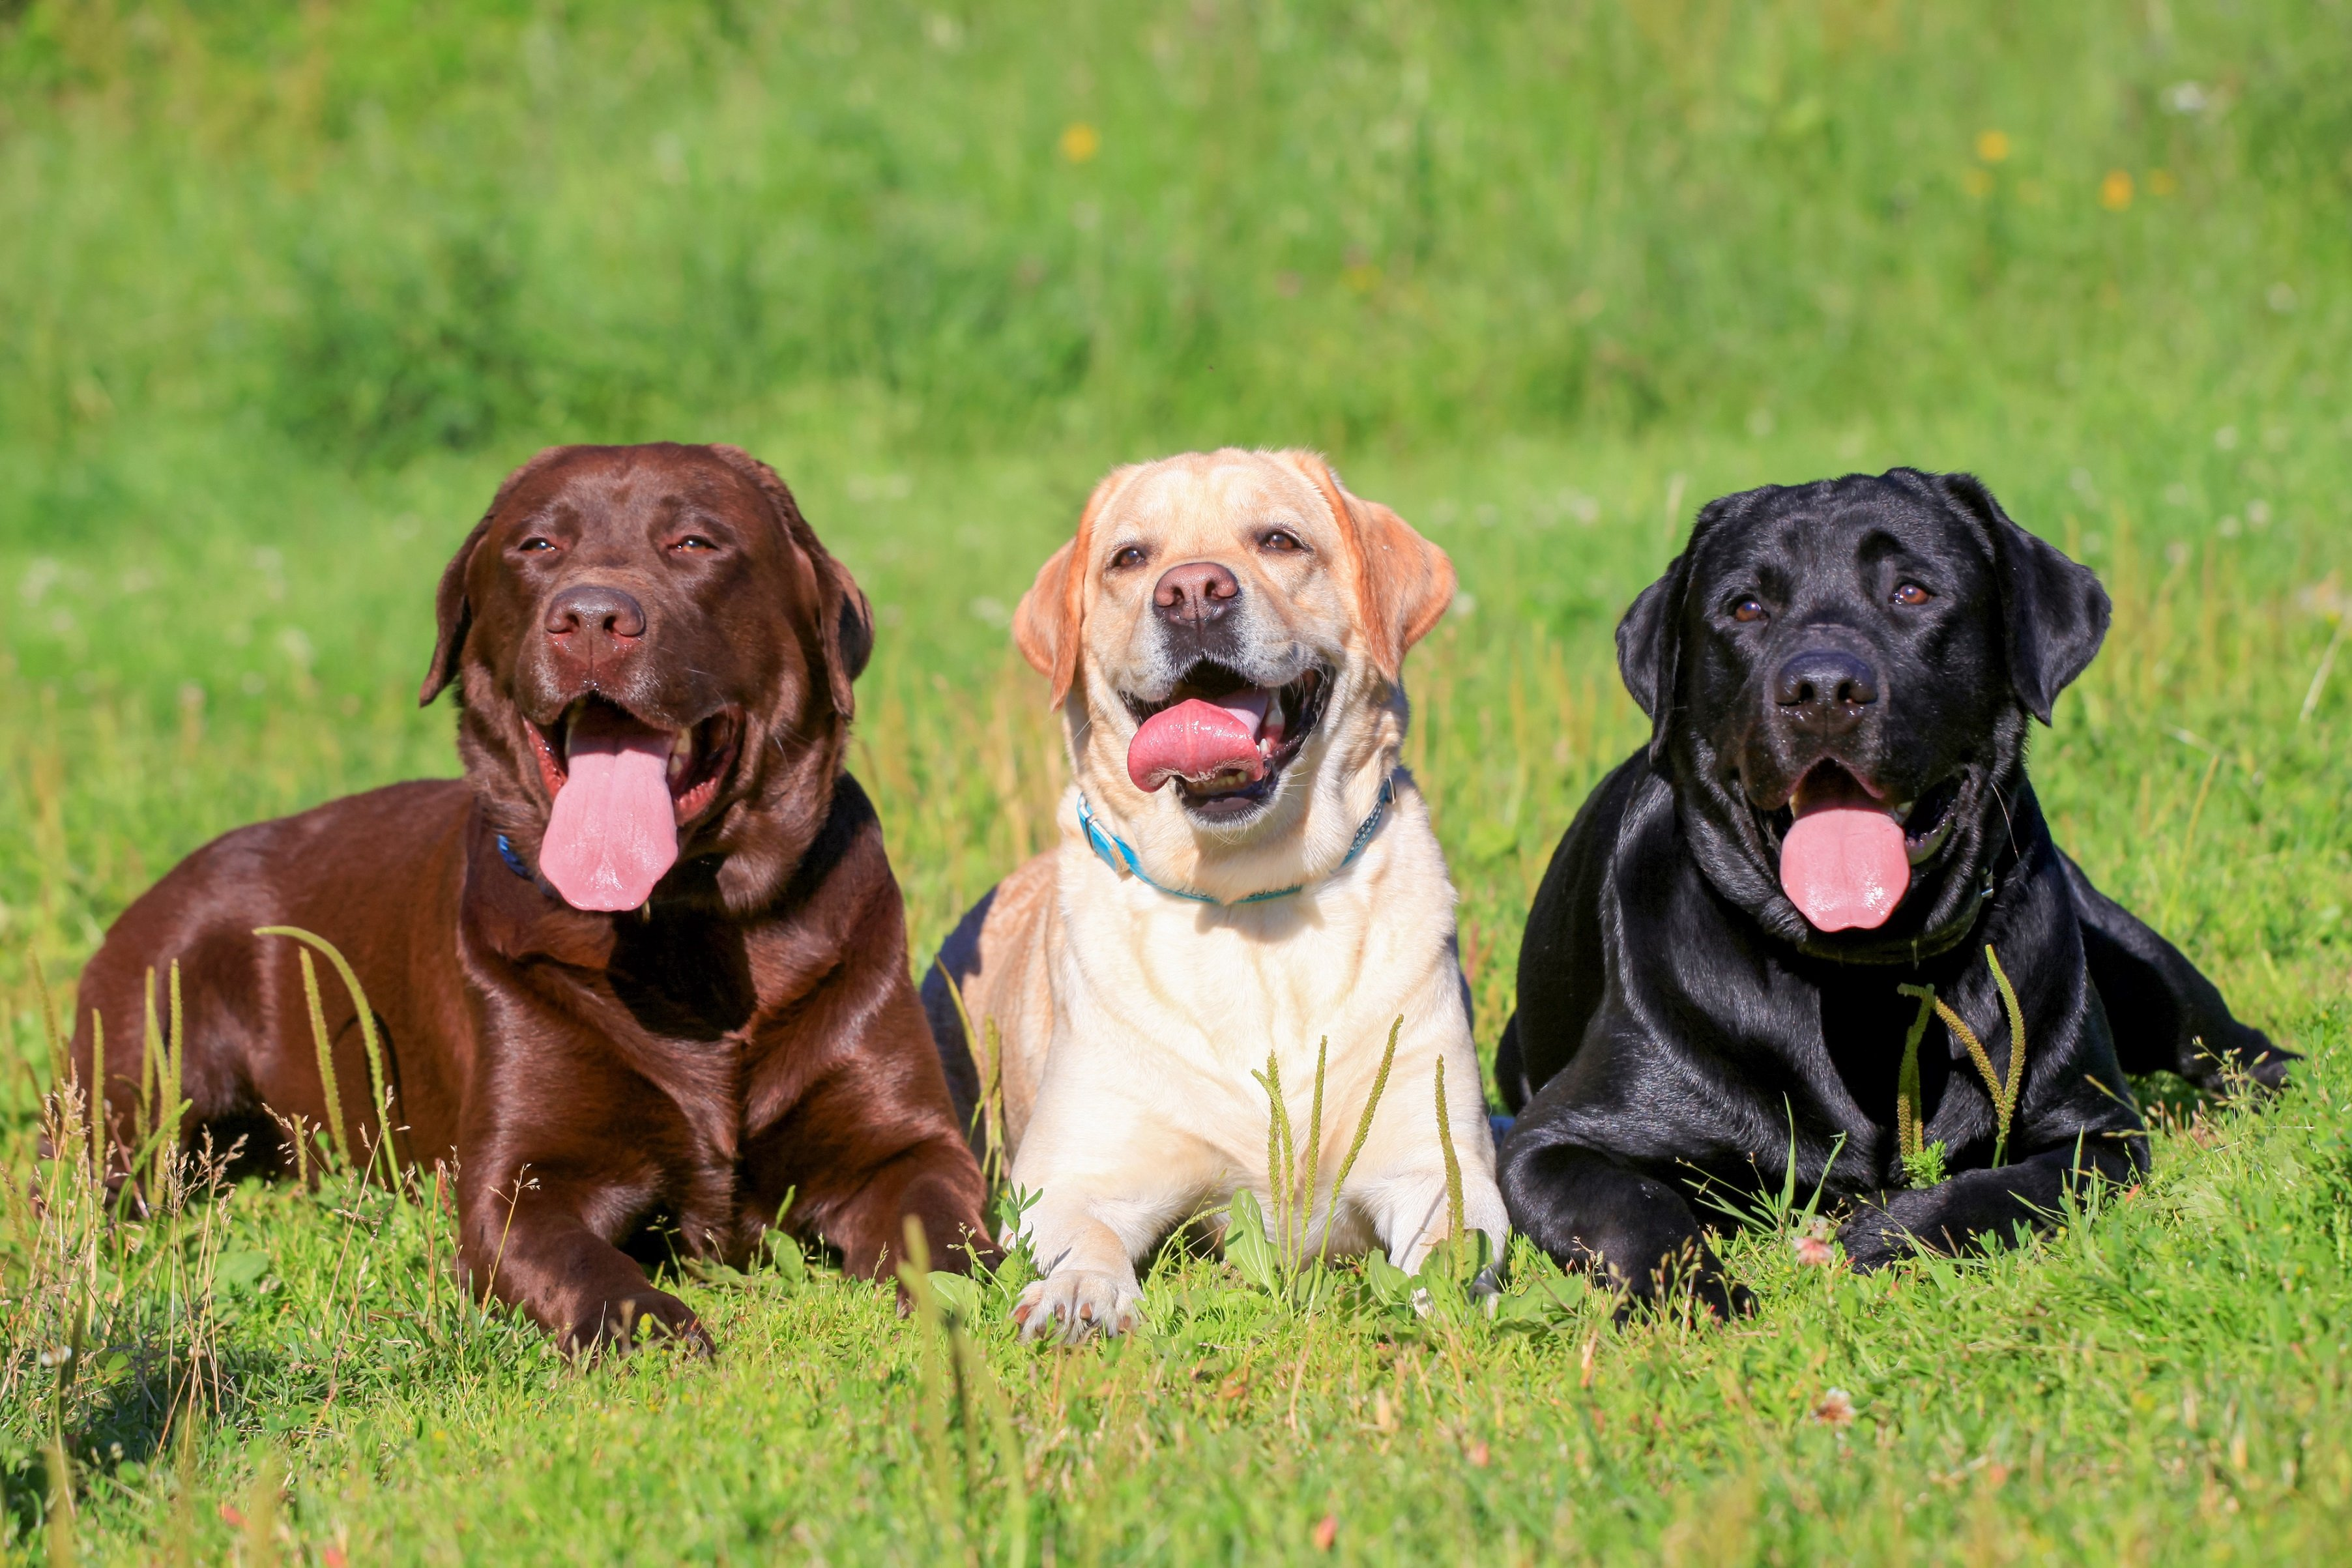

In [12]:
local_image_path = session8_dir() / "data" / "images" / "dogs.jpg"
display(Image(filename=str(local_image_path), width=500))

In [13]:
# Requires OPENAI_API_KEY
# Skip this cell if you do not have live API access.

client = make_openai_client(api_key=require_env("OPENAI_API_KEY"))
local_image_data_url = encode_image_to_data_url(local_image_path)

base64_image_response = client.responses.create(
    model=GENERATION_MODEL,
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "How many dogs are visible, and what colours are they? Answer in two short bullet points.",
                },
                {"type": "input_image", "image_url": local_image_data_url},
            ],
        }
    ],
)

display(Markdown(base64_image_response.output_text))

- There are three dogs visible.
- Their colors are brown, yellow, and black.

## 5. Provider Swap Pattern

The OpenAI SDK can also be used with compatible endpoints. This is useful for OpenAI and Ollama.

GitHub Models retired on 30 July 2026; its inference endpoints no longer work. See the [retirement notice](https://github.blog/changelog/2026-07-30-github-models-is-now-retired/). Select `SESSION8_PROVIDER=openai` (default) or `ollama` for the comparison below. This selector applies only to this comparison, not the OpenAI-specific cells above.


In [14]:
provider_examples = {
    "openai": {"base_url": None, "model": GENERATION_MODEL},
    "ollama": {"base_url": OLLAMA_BASE_URL,
               "model": os.getenv("OLLAMA_CHAT_MODEL", "llama3.2:latest")},
}
provider_examples


{'openai': {'base_url': None, 'model': 'gpt-4.1-mini'},
 'ollama': {'base_url': 'http://localhost:11434/v1',
  'model': 'llama3.2:latest'}}

In [15]:
# Select one provider so Run All does not require every optional service.
provider_name = os.getenv("SESSION8_PROVIDER", "openai")
provider = provider_examples[provider_name]
provider_api_key = require_env("OPENAI_API_KEY") if provider_name == "openai" else "ollama"
provider_client = make_openai_client(api_key=provider_api_key, base_url=provider["base_url"])
# Chat Completions is the shared compatibility example.
result = provider_client.chat.completions.create(
    model=provider["model"],
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user", "content": "Give one sentence explaining embeddings."},
    ],
)
display(Markdown(result.choices[0].message.content or "No text returned."))


Embeddings are numerical vector representations of data that capture semantic relationships, enabling machines to understand and process complex information like words, images, or documents.

## 6. Minimal Claude Comparison

Claude uses a different Python SDK and message structure. The main point here is contrast, not building a second full workflow.

In [16]:
# Requires ANTHROPIC_API_KEY
# Skip this cell if you do not have Claude access.

anthropic_client = anthropic.Anthropic(api_key=require_env("ANTHROPIC_API_KEY"))

claude_response = anthropic_client.messages.create(
    model=os.getenv("ANTHROPIC_MODEL", "claude-sonnet-4-6"),
    max_tokens=120,
    system="You are a concise teaching assistant.",
    messages=[
        {"role": "user", "content": "In one sentence, what is chunking in RAG?"}
    ],
)

display(Markdown(claude_response.content[0].text))

Chunking in RAG is the process of splitting large documents into smaller, manageable pieces of text so they can be efficiently indexed, retrieved, and passed to the language model within its context window.

## Recap

- We used the OpenAI SDK as the main teaching interface.
- Chat Completions and Responses API solve similar tasks with different shapes.
- Vision-capable models can take image and text together, either via remote URLs or base64-encoded local files.
- OpenAI and Ollama can often reuse the same client pattern.
- Claude is relevant, but it uses a different SDK and should be treated as a comparison point here.

The next notebook introduces embeddings and similarity before the PDF RAG pipeline.